In [2]:
import pynapple as nap
from monkeypaw.io import nap_load_data
# nwb_path = r"C:\Users\lilytong\Downloads\sub-Dataset-5-Animals-2-ses-1-to-19.nwb"
# nwb_path = r"C:\Users\lilytong\Downloads\sub-Dataset-3-Animals-1-to-4.nwb"
# nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-5-Animals-3&4\sub-Dataset-5-Animals-3&4.nwb"
# nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-3-Animals-1-to-4\sub-Dataset-3-Animals-1-to-4.nwb"
# nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-4-Animal-3-sess-1-to-6\sub-Dataset-4-Animal-3-sess-1-to-6.nwb"
nwb_path = r"C:\Users\lilytong\Documents\GitHub\NMA-shichimi-rulebreakerhalf-comparing-network\data\sub-Dataset-5-Animals-2-ses-20-to-39\sub-Dataset-5-Animals-2-ses-20-to-39.nwb"
data = nap_load_data(nwb_path)
data

Original keys: ['spikes_counts', 'trial_id', 'session', 'datasetID', 'animal', 'result', 'EventTarget_onset', 'EventGo_cue', 'targets_dir', 'cursor_vel_y', 'cursor_vel_x', 'cursor_pos_y', 'cursor_pos_x', 'cursor_acc_y', 'cursor_acc_x', 'Target_ID']
Renaming key 'EventTarget_onset' to 'EventTarget_Onset'
Renaming key 'targets_dir' to 'target_dir'
Renaming key 'Target_ID' to 'target_ID'


sub-Dataset-5-Animals-2-ses-20-to-39
┍━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━┑
│ Keys              │ Type     │
┝━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━┥
│ spikes_counts     │ TsdFrame │
│ trial_id          │ Tsd      │
│ session           │ Tsd      │
│ datasetID         │ Tsd      │
│ animal            │ Tsd      │
│ result            │ Tsd      │
│ EventGo_cue       │ Tsd      │
│ cursor_vel_y      │ Tsd      │
│ cursor_vel_x      │ Tsd      │
│ cursor_pos_y      │ Tsd      │
│ cursor_pos_x      │ Tsd      │
│ cursor_acc_y      │ Tsd      │
│ cursor_acc_x      │ Tsd      │
│ EventTarget_Onset │ Tsd      │
│ target_dir        │ Tsd      │
│ target_ID         │ Tsd      │
┕━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━┙

In [3]:
from monkeypaw.io import get_spike_count,get_behav,get_info

spike_count = get_spike_count(data)
behav = get_behav(data)
info = get_info(data)

In [4]:
info

Time (s)      trial_id    animal    datasetID    session    brain_region
----------  ----------  --------  -----------  ---------  --------------
0.0                  1         2            5         20             nan
0.01                 1         2            5         20             nan
0.02                 1         2            5         20             nan
0.03                 1         2            5         20             nan
0.04                 1         2            5         20             nan
0.05                 1         2            5         20             nan
0.06                 1         2            5         20             nan
...
17779.42           325         2            5         39             nan
17779.43           325         2            5         39             nan
17779.44           325         2            5         39             nan
17779.45           325         2            5         39             nan
17779.46           325         2            5  

In [7]:
spike_count

Time (s)              0    1    2    3    4  ...
------------------  ---  ---  ---  ---  ---  -----
0.0                   0    0    0    1    0  ...
0.03                  0    1    0    0    0  ...
0.06                  0    0    0    0    0  ...
0.09                  0    1    0    0    0  ...
0.12                  0    0    0    0    0  ...
0.15                  0    1    1    0    0  ...
0.18                  0    1    1    1    0  ...
...                                          ...
32235.059999999998    0    0    0    0    0  ...
32235.089999999997    1    0    0    0    1  ...
32235.12              0    0    0    0    0  ...
32235.149999999998    1    0    0    0    1  ...
32235.179999999997    0    0    0    0    2  ...
32235.21              1    0    0    0    0  ...
32235.239999999998    0    0    0    0    1  ...
dtype: float64, shape: (1074509, 121)

In [8]:
behav

Time (s)            EventGo_cue      EventTarget_onset    target_ID    target_dir  result    ...
------------------  -------------  -------------------  -----------  ------------  --------  -----
0.0                 False                          nan          nan       0        R         ...
0.03                False                          nan          nan       0        R         ...
0.06                False                          nan          nan       0        R         ...
0.09                False                          nan          nan       0        R         ...
0.12                False                          nan          nan       0        R         ...
0.15                False                          nan          nan       0        R         ...
0.18                False                          nan          nan       0        R         ...
...                                                                                          ...
32235.059999999998  False   

1074509 4 10 1038
7949


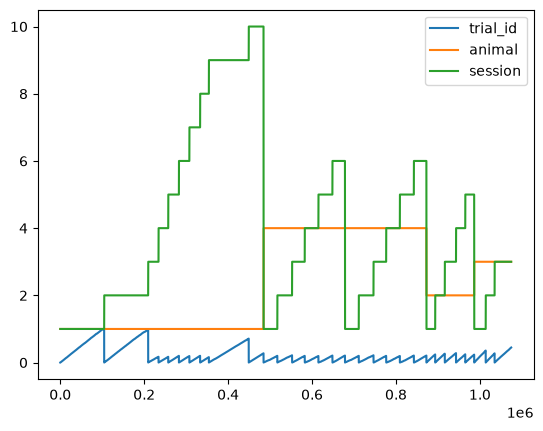

In [12]:
animal = info["animal"].data()
sess = info["session"].data()
trial_id = info["trial_id"].data()
import pandas as pd
tbl = pd.DataFrame({"animal": animal, "session": sess, "trial_id": trial_id})
print(len(tbl), len(tbl["animal"].unique()), len(tbl["session"].unique()), len(tbl["trial_id"].unique()))
print(len(tbl.drop_duplicates(subset=["animal", "session", "trial_id"])))
import matplotlib.pyplot as plt
plt.plot(tbl["trial_id"].to_numpy()/max(tbl["trial_id"].to_numpy()),label = "trial_id")
plt.plot(tbl["animal"].to_numpy(),label = "animal")
plt.plot(tbl["session"].to_numpy(),label = "session")
plt.legend()
plt.show()